# Importing Libraries:

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colorbar
from matplotlib.animation import FuncAnimation

# Defining Layout: These are the keys and characters for the QWERTY layout

In [4]:
# Provided keyboard layout with positions and characters
keys = {
    # Number row
    '`': {'pos': (0, 4), 'start': 'a'}, '1': {'pos': (1, 4), 'start': 'a'}, '2': {'pos': (2, 4), 'start': 'a'},
    '3': {'pos': (3, 4), 'start': 's'}, '4': {'pos': (4, 4), 'start': 'd'}, '5': {'pos': (5, 4), 'start': 'f'},
    '6': {'pos': (6, 4), 'start': 'j'}, '7': {'pos': (7, 4), 'start': 'j'}, '8': {'pos': (8, 4), 'start': 'k'},
    '9': {'pos': (9, 4), 'start': 'l'}, '0': {'pos': (10, 4), 'start': ';'}, '-': {'pos': (11, 4), 'start': ';'},
    '=': {'pos': (12, 4), 'start': ';'},'Backspace': {'pos': (13.5, 4), 'start': ';'},

    # Top letter row
    'Tab':{'pos': (0.5, 3), 'start': 'a'},
    'q': {'pos': (1.5, 3), 'start': 'a'}, 'w': {'pos': (2.5, 3), 'start': 's'}, 'e': {'pos': (3.5, 3), 'start': 'd'},
    'r': {'pos': (4.5, 3), 'start': 'f'}, 't': {'pos': (5.5, 3), 'start': 'f'}, 'y': {'pos': (6.5, 3), 'start': 'j'},
    'u': {'pos': (7.5, 3), 'start': 'j'}, 'i': {'pos': (8.5, 3), 'start': 'k'}, 'o': {'pos': (9.5, 3), 'start': 'l'},
    'p': {'pos': (10.5, 3), 'start': ';'}, '[': {'pos': (11.5, 3), 'start': ';'}, ']': {'pos': (12.5, 3), 'start': ';'},
    '\\': {'pos': (13.5, 3), 'start': ';'},

    # Home row
    'CapsLk': {'pos': (0.75, 2), 'start': 'a'},
    'a': {'pos': (1.75, 2), 'start': 'a'}, 's': {'pos': (2.75, 2), 'start': 's'}, 'd': {'pos': (3.75, 2), 'start': 'd'},
    'f': {'pos': (4.75, 2), 'start': 'f'}, 'g': {'pos': (5.75, 2), 'start': 'f'}, 'h': {'pos': (6.75, 2), 'start': 'j'},
    'j': {'pos': (7.75, 2), 'start': 'j'}, 'k': {'pos': (8.75, 2), 'start': 'k'}, 'l': {'pos': (9.75, 2), 'start': 'l'},
    ';': {'pos': (10.75, 2), 'start': ';'}, "'": {'pos': (11.75, 2), 'start': ';'},"Enter": {'pos': (12.75, 2), 'start': ';'},

    # Bottom letter row
    'z': {'pos': (2.25, 1), 'start': 'a'}, 'x': {'pos': (3.25, 1), 'start': 's'}, 'c': {'pos': (4.25, 1), 'start': 'd'},
    'v': {'pos': (5.25, 1), 'start': 'f'}, 'b': {'pos': (6.25, 1), 'start': 'f'}, 'n': {'pos': (7.25, 1), 'start': 'j'},
    'm': {'pos': (8.25, 1), 'start': 'j'}, ',': {'pos': (9.25, 1), 'start': 'k'}, '.': {'pos': (10.25, 1), 'start': 'l'},
    '/': {'pos': (11.25, 1), 'start': ';'},

    # Special keys
    'Shift_L': {'pos': (0, 1), 'start': 'a'}, 'Shift_R': {'pos': (12.5, 1), 'start': ';'},
    'Ctrl_L': {'pos': (0, 0), 'start': 'a'}, 'Alt_L': {'pos': (2, 0), 'start': 'a'},
    'Space': {'pos': (5, 0), 'start': 'f'}, 'Alt_R': {'pos': (8, 0), 'start': 'j'}, 'Ctrl_R': {'pos': (10, 0), 'start': ';'},
}

characters = {
    # Lowercase letters (unchanged)
    'a': ('a',), 'b': ('b',), 'c': ('c',), 'd': ('d',), 'e': ('e',),
    'f': ('f',), 'g': ('g',), 'h': ('h',), 'i': ('i',), 'j': ('j',),
    'k': ('k',), 'l': ('l',), 'm': ('m',), 'n': ('n',), 'o': ('o',),
    'p': ('p',), 'q': ('q',), 'r': ('r',), 's': ('s',), 't': ('t',),
    'u': ('u',), 'v': ('v',), 'w': ('w',), 'x': ('x',), 'y': ('y',),
    'z': ('z',),

    # Uppercase letters (updated)
    'A': ('Shift_R', 'a'), 'B': ('Shift_R', 'b'), 'C': ('Shift_R', 'c'),
    'D': ('Shift_R', 'd'), 'E': ('Shift_R', 'e'), 'F': ('Shift_R', 'f'),
    'G': ('Shift_R', 'g'), 'H': ('Shift_L', 'h'), 'I': ('Shift_L', 'i'),
    'J': ('Shift_L', 'j'), 'K': ('Shift_L', 'k'), 'L': ('Shift_L', 'l'),
    'M': ('Shift_L', 'm'), 'N': ('Shift_L', 'n'), 'O': ('Shift_L', 'o'),
    'P': ('Shift_L', 'p'), 'Q': ('Shift_R', 'q'), 'R': ('Shift_R', 'r'),
    'S': ('Shift_R', 's'), 'T': ('Shift_R', 't'), 'U': ('Shift_L', 'u'),
    'V': ('Shift_R', 'v'), 'W': ('Shift_R', 'w'), 'X': ('Shift_R', 'x'),
    'Y': ('Shift_L', 'y'), 'Z': ('Shift_R', 'z'),

    # Numbers and their shifted symbols (updated)
    '1': ('1',), '!': ('Shift_R', '1'),
    '2': ('2',), '@': ('Shift_R', '2'),
    '3': ('3',), '#': ('Shift_R', '3'),
    '4': ('4',), '$': ('Shift_R', '4'),
    '5': ('5',), '%': ('Shift_R', '5'),
    '6': ('6',), '^': ('Shift_L', '6'),
    '7': ('7',), '&': ('Shift_L', '7'),
    '8': ('8',), '*': ('Shift_L', '8'),
    '9': ('9',), '(': ('Shift_L', '9'),
    '0': ('0',), ')': ('Shift_L', '0'),

    # Other symbols (updated)
    '`': ('`',), '~': ('Shift_R', '`'),    # modified this from '' to '`'
    '-': ('-',), '_': ('Shift_L', '-'),
    '=': ('=',), '+': ('Shift_L', '='),
    '[': ('[',), '{': ('Shift_L', '['),
    ']': (']',), '}': ('Shift_L', ']'),
    '\\': ('\\',), '|': ('Shift_L', '\\'),
    ';': (';',), ':': ('Shift_L', ';'),
    "'": ("'",), '"': ('Shift_L', "'"),
    ',': (',',), '<': ('Shift_L', ','),
    '.': ('.',), '>': ('Shift_L', '.'),
    '/': ('/',), '?': ('Shift_L', '/'),

    # Space (unchanged)
    ' ': ('Space',),
}


## Extracting the keys that will also contain characters produced by shift combinations in the form of a dictionary for better usage-

In [5]:
Shift_characters = {                #This is made from characters dictionary from the layout, by only extracting the keys with which if shift is pressed we get a new character and the corresponding new character (adjacent to it)
    '1': ('1',), '!': ('Shift_R', '1'),
    '2': ('2',), '@': ('Shift_R', '2'),
    '3': ('3',), '#': ('Shift_R', '3'),
    '4': ('4',), '$': ('Shift_R', '4'),
    '5': ('5',), '%': ('Shift_R', '5'),
    '6': ('6',), '^': ('Shift_L', '6'),
    '7': ('7',), '&': ('Shift_L', '7'),
    '8': ('8',), '*': ('Shift_L', '8'),
    '9': ('9',), '(': ('Shift_L', '9'),
    '0': ('0',), ')': ('Shift_L', '0'),

    # Other symbols (updated)
    '`': ('`',), '~': ('Shift_R', '`'),
    '-': ('-',), '_': ('Shift_L', '-'),
    '=': ('=',), '+': ('Shift_L', '='),
    '[': ('[',), '{': ('Shift_L', '['),
    ']': (']',), '}': ('Shift_L', ']'),
    '\\': ('\\',), '|': ('Shift_L', '\\'),
    ';': (';',), ':': ('Shift_L', ';'),
    "'": ("'",), '"': ('Shift_L', "'"),
    ',': (',',), '<': ('Shift_L', ','),
    '.': ('.',), '>': ('Shift_L', '.'),
    '/': ('/',), '?': ('Shift_L', '/')
}

# Here I create a dictionary containing the normal character and the corresponding shift character of a key. e.g '1': '!'
# I do so, by considering key value pairs from Shift_characters dictionary, whose values tuple contains more than 2 elements and starts with shift and take the normal key as base and the key as shift.
Shift_characters_simplified = {

    base: shift                                         # dictionary has key value pairs as base : shift
    for shift, values in Shift_characters.items()       # here values is a tuple either of length 1 or 2 (if Shift_L/ Shift_R is present)
    if len(values) > 1 and values[0].startswith('Shift') # conditioning for accepting a key from Shift_characters
    for base in values[1:]                               # the normal key is the second element of the values tuple
}

print(Shift_characters_simplified)

{'1': '!', '2': '@', '3': '#', '4': '$', '5': '%', '6': '^', '7': '&', '8': '*', '9': '(', '0': ')', '`': '~', '-': '_', '=': '+', '[': '{', ']': '}', '\\': '|', ';': ':', "'": '"', ',': '<', '.': '>', '/': '?'}


# Creating a visualisation of a plain keyboard with the above layout

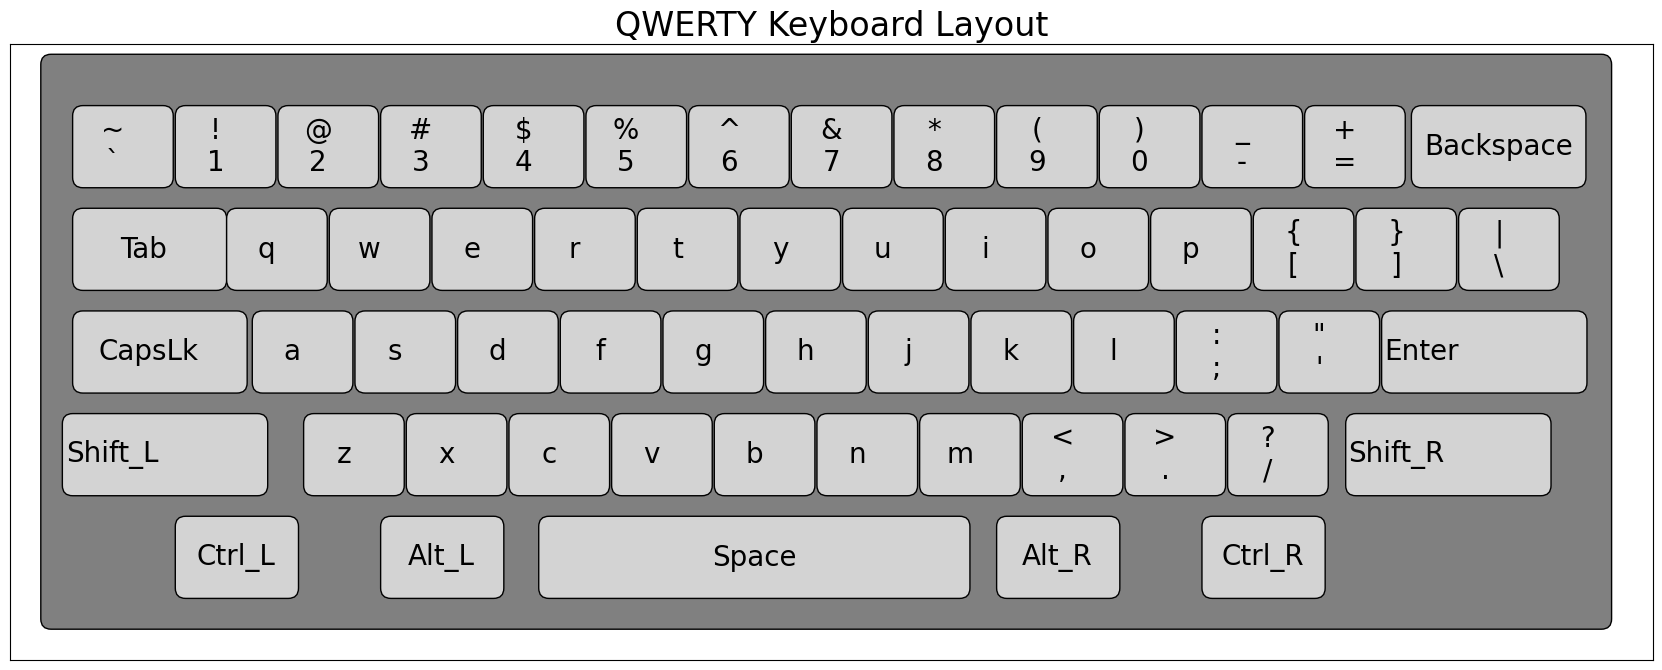

In [6]:
# Key dimensions: these will help adjust the position of the patches around the keys
key_height = 0.6                      # Height of all keys
normal_key_width = 0.78               # Width of regular keys
space_key_width = 4                   # Custom width for the space key
back_space_key_width = 1.5            # Custom width of the backspace key


fig, ax = plt.subplots(figsize=(24, 8))      # Creaitng the figure and axis for plotting

# Adding a backgound in the shape of a rounded rectangle
background_rect = patches.FancyBboxPatch((-0.6, -0.6), 15.1, 5.4, boxstyle="round,pad=0.1", edgecolor="black", facecolor="grey")
ax.add_patch(background_rect)

# Iterate over each key in the layout and place it on the plot
for key, info in keys.items():
    x, y = info['pos']  # Extract the (x, y) position of the key, from the layout

    # consideering special keys for manual adjustment and alignment of Patches
    if key == 'Space':
        rect = patches.FancyBboxPatch((x - space_key_width / 2 + 1.25, y - 0.3), space_key_width, key_height,
                                       boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")             # Place the leftbottom most corner of space bar at this loaction
        ax.add_patch(rect)
        ax.text(x + 1.25, y, key, ha='center', va='center', fontsize=20)                                               # Placing text at the centre of spacebar


    elif key == 'Backspace':
        rect = patches.FancyBboxPatch((x - back_space_key_width / 2 , y - 0.3), back_space_key_width, key_height,
                                       boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")              # All the keys are plotted in light grey to distinguish from bg grey
        ax.add_patch(rect)
        ax.text(x, y, key, ha='center', va='center', fontsize=20)

    elif key == "Tab":
        rect = patches.FancyBboxPatch((-0.29, 2.7), back_space_key_width - 0.2, key_height,
                                       boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
        ax.add_patch(rect)
        ax.text(x - 0.2 , y, key, ha='center', va='center', fontsize=20)

    elif key == "CapsLk" :
      rect = patches.FancyBboxPatch((-0.29, 1.7), back_space_key_width, key_height,
                                       boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
      ax.add_patch(rect)
      ax.text(x - 0.4 , y, key, ha='center', va='center', fontsize=20)

    elif key == "Enter":
      rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 , y - key_height / 2),
                                            1.8, key_height,
                                           boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
      ax.add_patch(rect)
      ax.text(x , y, key, ha='center', va='center', fontsize=20)

    elif key == "Shift_L" or key == "Shift_R":
      rect = patches.FancyBboxPatch((x - normal_key_width / 2 , y - key_height / 2),
                                            1.8, key_height,
                                           boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
      ax.add_patch(rect)
      ax.text(x , y, key, ha='center', va='center', fontsize=20)

    # Considering all the remaining keys
    else:
        # Check for shift characters, t print both shift character and normal character in the same key
        if key in Shift_characters_simplified.keys():
            special = Shift_characters_simplified[key]
            rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1, y - key_height / 2),
                                           normal_key_width, key_height,
                                           boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
            ax.add_patch(rect)
            ax.text(x, y, f"{special}\n{key}", ha='center', va='center', fontsize=20)           #Using format string for taking in the special and normal key at once

        else:
            # Drawing normal keys
            if y ==0 :   # to enssure proper alignment of the botom most row
              rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 + 1 , y - key_height / 2),
                                           1, key_height,
                                           boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
              ax.add_patch(rect)
              ax.text(x + 1.2, y, key, ha='center', va='center', fontsize=20)    # Doesn't impact distance measure as we won't be using these in paragraphs
            else:
              # Every other remaining row
              rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 , y - key_height / 2),
                                            normal_key_width, key_height,
                                            boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
              ax.add_patch(rect)
              ax.text(x, y, key, ha='center', va='center', fontsize=20)




ax.set_aspect('equal')
# Formatting the plot to look like a keyboard
ax.set_xlim(-1, 15)
ax.set_ylim(-1, 5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("QWERTY Keyboard Layout", fontsize=24)

# Show the plot
plt.show()


# Creating the heatmap of the same layout based on key frequency :

In [7]:
# Function to calculate frequency of keys from the input text
def freq_dic_creator(input_string, keys, characters):
  ''' This function is used to return a frequency dictionary that contains every character and their corresponding frequencies including shifts, space, etc.
  By iterating through the elements of a string and checks characters dictionary with element as a key. Uses the values tuple to update the frequency of ch character in the values tuple (This accounts for characters made with combination)'''
  freq_dic = {}
  for i in input_string:
    freq_dic[characters[i][0]] = freq_dic.get(characters[i][0], 0) + 1            # checks characters dictionary for a key, characters[i]0] is a tuple with either len  1 or 2,
                                                                                  # if there or not in dictionary already, adds 1 to existing frequency or 0.
    if len(characters[i]) > 1:                                                    # if len > 2 it means there is a combination involved, so it consides all characters of combination in the freq_dic.
      freq_dic[characters[i][1]] = freq_dic.get(characters[i][1], 0) + 1
  return freq_dic


In [12]:
# Function to generate heatmap based on key frequencies
def generate_heatmap(ax, text, keys, characters):
    '''Generates a heatmap on a keyboard layout based on character
    frequency in the input text'''

    frequencies = freq_dic_creator(text, keys, characters)     #Creating a frequency dictionary
    if 'Space' in frequencies.keys():                          #Ignoring Space, as it can lead to a skwewed distriution in paragraphs
      del frequencies["Space"]

    # Prepare heatmap data
    heatmap_data = np.zeros((5, 14))              # Initialize a 5x14 matrix for the heatmap data (this represents the 5 rows of the keyboard and 14 keys per row)
    for key, info in keys.items():
        if key in frequencies:
            x, y = info['pos']
            heatmap_data[int(y), int(x)] = frequencies[key]        #Populate the heatmap with frequencies based on the position of each key, int choses the integral positionsbut or apcing is suffiencient to not cause any issue here

    # Draw the heatmap
    for key, info in keys.items():
        x, y = info['pos']
        heat = heatmap_data[int(y), int(x)]                            # Retrieves the frequency of key presses for the current key from the heatmap dtaa matrix
        color_intensity = min(1, heat / max(frequencies.values())) if max(frequencies.values()) > 0 else 0  #The color intensity is normalized by dividing the key's frequency by the maximum frequency, capping it at 1, and defaulting to 0 if there are no key presses.
        color =  plt.cm.PuRd(color_intensity)   # Heatmap color gradient, the color intensity value is used to pick the appropriate color from the colormap PuRd


        # Using the same keyboard layout we defined earlier, except changing the color to the color of key based on heatmap
        if key == 'Space':
            rect = patches.FancyBboxPatch((x - space_key_width / 2 + 1.25, y - 0.3), space_key_width, key_height,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
            ax.add_patch(rect)
            ax.text(x  + 1.25, y, key, ha='center', va='center', fontsize=20)


        elif key == 'Backspace':
            rect = patches.FancyBboxPatch((x - back_space_key_width / 2 , y - 0.3), back_space_key_width, key_height,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
            ax.add_patch(rect)
            ax.text(x, y, key, ha='center', va='center', fontsize=20)
        elif key == "Tab":
            rect = patches.FancyBboxPatch((-0.29, 2.7), back_space_key_width - 0.2, key_height,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
            ax.add_patch(rect)
            ax.text(x - 0.2 , y, key, ha='center', va='center', fontsize=20)
        elif key == "CapsLk" :
          rect = patches.FancyBboxPatch((-0.29, 1.7), back_space_key_width, key_height,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
          ax.add_patch(rect)
          ax.text(x - 0.4 , y, key, ha='center', va='center', fontsize=20)\

        elif key == "Enter":
          rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 , y - key_height / 2),
                                                1.8, key_height,
                                              boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
          ax.add_patch(rect)
          ax.text(x , y, key, ha='center', va='center', fontsize=20)

        elif key == "Shift_L" or key == "Shift_R":
          rect = patches.FancyBboxPatch((x - normal_key_width / 2 , y - key_height / 2),
                                                1.8, key_height,
                                              boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
          ax.add_patch(rect)
          ax.text(x , y, key, ha='center', va='center', fontsize=20)


        else:
            if key in Shift_characters_simplified.keys():
                special = Shift_characters_simplified[key]
                rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1, y - key_height / 2),
                                              normal_key_width, key_height,
                                              boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
                ax.add_patch(rect)
                ax.text(x, y, f"{special}\n{key}", ha='center', va='center', fontsize=20)

            else:
                if y ==0 :
                  rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 + 1 , y - key_height / 2),
                                              1, key_height,
                                              boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
                  ax.add_patch(rect)
                  ax.text(x + 1.2, y, key, ha='center', va='center', fontsize=20)
                else:

                  rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 , y - key_height / 2),
                                                normal_key_width, key_height,
                                                boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
                  ax.add_patch(rect)
                  ax.text(x, y, key, ha='center', va='center', fontsize=20)

    return heatmap_data                            # This is requied plot the color scale



def Plotter(text_input, keys, characters):
  ''' This function diplays frequencies dictionary and the heatmap plot with the color scale'''

  frequencies = freq_dic_creator(text_input, keys, characters)
  print(frequencies)
  fig, ax = plt.subplots(figsize=(24, 8))

  # Plotting background rectangle for visual clarity
  background_rect = patches.FancyBboxPatch((-0.6, -0.6), 15.1, 5.4,
                                            boxstyle="round,pad=0.1", edgecolor="black", facecolor="grey")
  ax.add_patch(background_rect)
  generate_heatmap(ax, text_input, keys, characters)

  # Formatting the plot to look like a keyboard
  ax.set_xlim(-1, 15)
  ax.set_ylim(-1, 5)
  ax.set_xticks([])
  ax.set_yticks([])
  ax.set_title("QWERTY Keyboard Heatmap", fontsize=24)

  # Adding color scale
  heatmap_data = generate_heatmap(ax, text_input, keys, characters)
  norm = plt.Normalize(vmin=0, vmax=np.max(heatmap_data))    # Normalize the heatmap data for the color map, setting the minimum value to 0 and maximum to the highest frequency in heatmap_data
  sm = plt.cm.ScalarMappable(cmap="PuRd", norm=norm)         # Create a ScalarMappable object with the "PuRd" color map and the defined normalization
  sm.set_array([])
  cbar = plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.01)  #Add a colorbar to the plot, using the ScalarMappable (sm) for coloring and setting its orientation to vertical
  cbar.set_label('Key Frequency', fontsize=16)                      # Setting labels
  plt.show()


#Distance Calculation :

*   Calculates distances travelled by fingers while tying an input string, assumes space keys' start position is at 'f'



In [13]:
def calculate_distance(text_input, keys, characters):

  ''' Calculates total distance by using the characters dictionary and for each element in value tuple,
  calculating distanes from corresponfing home row keys and adding them up, giving the total distance of a single
  character. Adding those up for all characters yields total distance'''

  total = 0       # initialising total  = 0 for a string
  total_1 = 0     # initialising total = 0 for each character in string
  for c in text_input:
      total_1 = 0
      chars = characters[c] # is a tuple, now calulating total distance:
      for i in chars:
          details = keys[i]                      # extracting details like position and start, of elements in the chars (/value) tuple from the keys dictionary
          pos1 = details['pos']
          start_char = details['start']
          start_pt_details = keys[start_char]    # extarcting details for the start (home row) key as well
          pos2 = start_pt_details['pos']
          dis = (((pos1[0]- pos2[0])**2) + ((pos1[1]- pos2[1])**2))**(0.5)    # Using distance formula
          total_1 += dis
      total += total_1
  return total

# Considering, space key to have start from f


# Animation - capturing finger travel and visualising keys like Shift:

In [14]:
# Function to update heatmap data dynamically
def update_heatmap(frequencies, keys, characters, i):
    """
    Update the heatmap data based on the frequencies of key presses up to the ith character.
    i =  The index in the input text to consider for counting key presses.
    Returns:
    numpy.ndarray: A 2D array representing the updated heatmap data.
    """
    if 'Space' in frequencies.keys():
      del frequencies["Space"]      # removing space key from visualisation
    heatmap_data = np.zeros((5, 14))
    for char in text_input[:i]:    # Iterate through the input text up to the ith character
        if char in characters and char != " ":
          # Iterate through all keys corresponding to the character
          for k in range(len(characters[char])):
              key = characters[char][k]
              if key in frequencies:
                  x, y = keys[key]['pos']
                  heatmap_data[int(y), int(x)] += 1     # update each time we hit the key ( heatmap data is just the frequencies)
    return heatmap_data


# Function to generate the heatmap for animation
def generate_animated_heatmap(i):
    # Clear any previous patches
    ax.clear()

    # Update the heatmap based on the current frame `i`
    frequencies = freq_dic_creator(text_input, keys, characters)
    heatmap_data = update_heatmap(frequencies, keys, characters, i)   ## This is the difference between generate_animated_heatmap(i) and generate_heatmap functions ( LIVE HEATMAP UPDATION)
    background_rect = patches.FancyBboxPatch((-0.6, -0.6), 15.1, 5.4,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor="grey")
    ax.add_patch(background_rect)

    # Draw the updated heatmap
    for key, info in keys.items():
        x, y = info['pos']
        heat = heatmap_data[int(y), int(x)]
        color_intensity = min(1, heat / max(frequencies.values())) if max(frequencies.values()) > 0 else 0
        color =  plt.cm.PuRd(color_intensity)
        if key == 'Space':
            rect = patches.FancyBboxPatch((x - space_key_width / 2 + 1.25, y - 0.3), space_key_width, key_height,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
            ax.add_patch(rect)
            ax.text(x  + 1.25, y, key, ha='center', va='center', fontsize=20)

        elif key == 'Backspace':
            rect = patches.FancyBboxPatch((x - back_space_key_width / 2 , y - 0.3), back_space_key_width, key_height,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
            ax.add_patch(rect)
            ax.text(x, y, key, ha='center', va='center', fontsize=20)
        elif key == "Tab":
            rect = patches.FancyBboxPatch((-0.29, 2.7), back_space_key_width - 0.2, key_height,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
            ax.add_patch(rect)
            ax.text(x - 0.2 , y, key, ha='center', va='center', fontsize=20)
        elif key == "CapsLk" :
          rect = patches.FancyBboxPatch((-0.29, 1.7), back_space_key_width, key_height,
                                          boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
          ax.add_patch(rect)
          ax.text(x - 0.4 , y, key, ha='center', va='center', fontsize=20)\

        elif key == "Enter":
          rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 , y - key_height / 2),
                                                1.8, key_height,
                                              boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
          ax.add_patch(rect)
          ax.text(x , y, key, ha='center', va='center', fontsize=20)

        elif key == "Shift_L" or key == "Shift_R":
          rect = patches.FancyBboxPatch((x - normal_key_width / 2 , y - key_height / 2),
                                                1.8, key_height,
                                              boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
          ax.add_patch(rect)
          ax.text(x , y, key, ha='center', va='center', fontsize=20)


        else:

            if key in Shift_characters_simplified.keys():
                special = Shift_characters_simplified[key]
                rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1, y - key_height / 2),
                                              normal_key_width, key_height,
                                              boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
                ax.add_patch(rect)
                ax.text(x, y, f"{special}\n{key}", ha='center', va='center', fontsize=20)

            else:

                if y ==0 :
                  rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 + 1 , y - key_height / 2),
                                              1, key_height,
                                              boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
                  ax.add_patch(rect)
                  ax.text(x + 1.2, y, key, ha='center', va='center', fontsize=20)
                else:

                  rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 , y - key_height / 2),
                                                normal_key_width, key_height,
                                                boxstyle="round,pad=0.1", edgecolor="black", facecolor= color)
                  ax.add_patch(rect)
                  ax.text(x, y, key, ha='center', va='center', fontsize=20)



    # Set limits, remove ticks, and set title
    ax.set_xlim(-1, 15)
    ax.set_ylim(-1, 5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Heatmap - Processing input character: {text_input[:i]}", fontsize=24)         # Dynamic heading to help visualise better



#Example 1 :

{'Shift_L': 1, 'h': 2, 'e': 2, 'l': 3, 'o': 2, 'Space': 6, 'Shift_R': 3, 'w': 1, 'r': 2, 'd': 1, '1': 1, 't': 4, 'i': 3, 's': 4, 'a': 1, 'n': 1, 'g': 1, '.': 1}


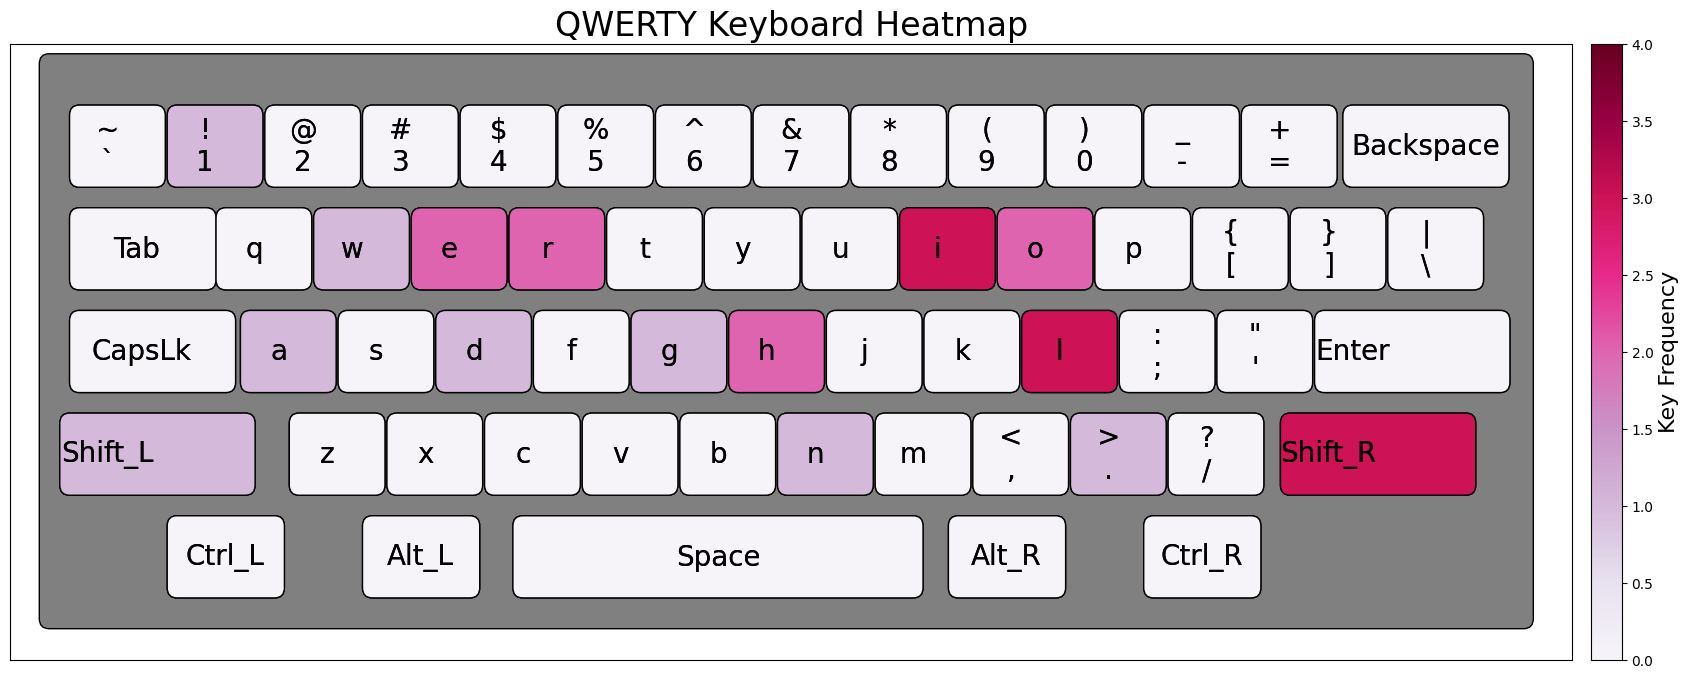

Total distance travelled by the fingers 42.83547734861969


In [15]:
# Example usage with text input
text_input = "Hello World! This is a test string."

Plotter(text_input, keys, characters)
total_distance = calculate_distance(text_input, keys, characters)
print("Total distance travelled by the fingers", total_distance)

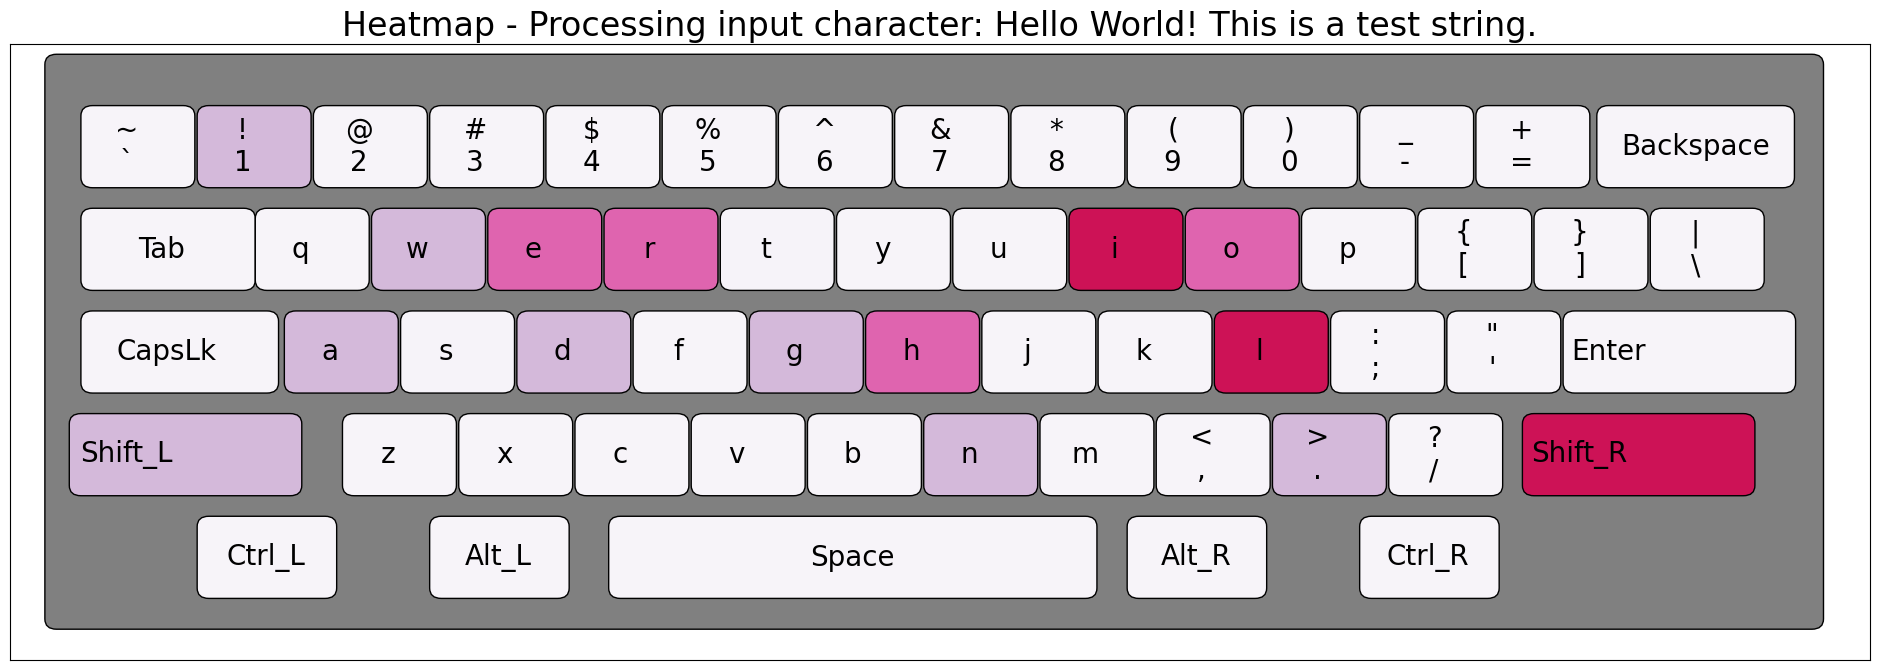

In [16]:
# Initialize the figure and axis
fig, ax = plt.subplots(figsize=(24, 8))

# Create the animation using FuncAnimation
anim = FuncAnimation(fig, generate_animated_heatmap, frames=len(text_input) + 1, interval=500, repeat=False)
anim.save('heatmap_animation_text_input1.mp4', writer='ffmpeg')
# Show the animated plot
plt.show()

#Example 2 :

{'Shift_R': 18, 't': 22, 'h': 7, 'e': 23, 'Space': 65, 'q': 2, 'u': 6, 'i': 12, 'c': 13, 'k': 4, 'b': 3, 'r': 11, 'o': 24, 'w': 5, 'n': 16, 'f': 6, 'x': 2, 'j': 2, 'm': 9, 'p': 8, 's': 15, 'v': 2, 'l': 6, 'a': 14, 'z': 1, 'y': 6, 'd': 10, 'g': 4, '1': 5, '2': 5, 'Shift_L': 17, ';': 3, '3': 3, '4': 4, ',': 8, '0': 5, '5': 1, '6': 2, '7': 1, '8': 1, '9': 2, '.': 7, '=': 4, "'": 1, '[': 2, ']': 2, '/': 1}


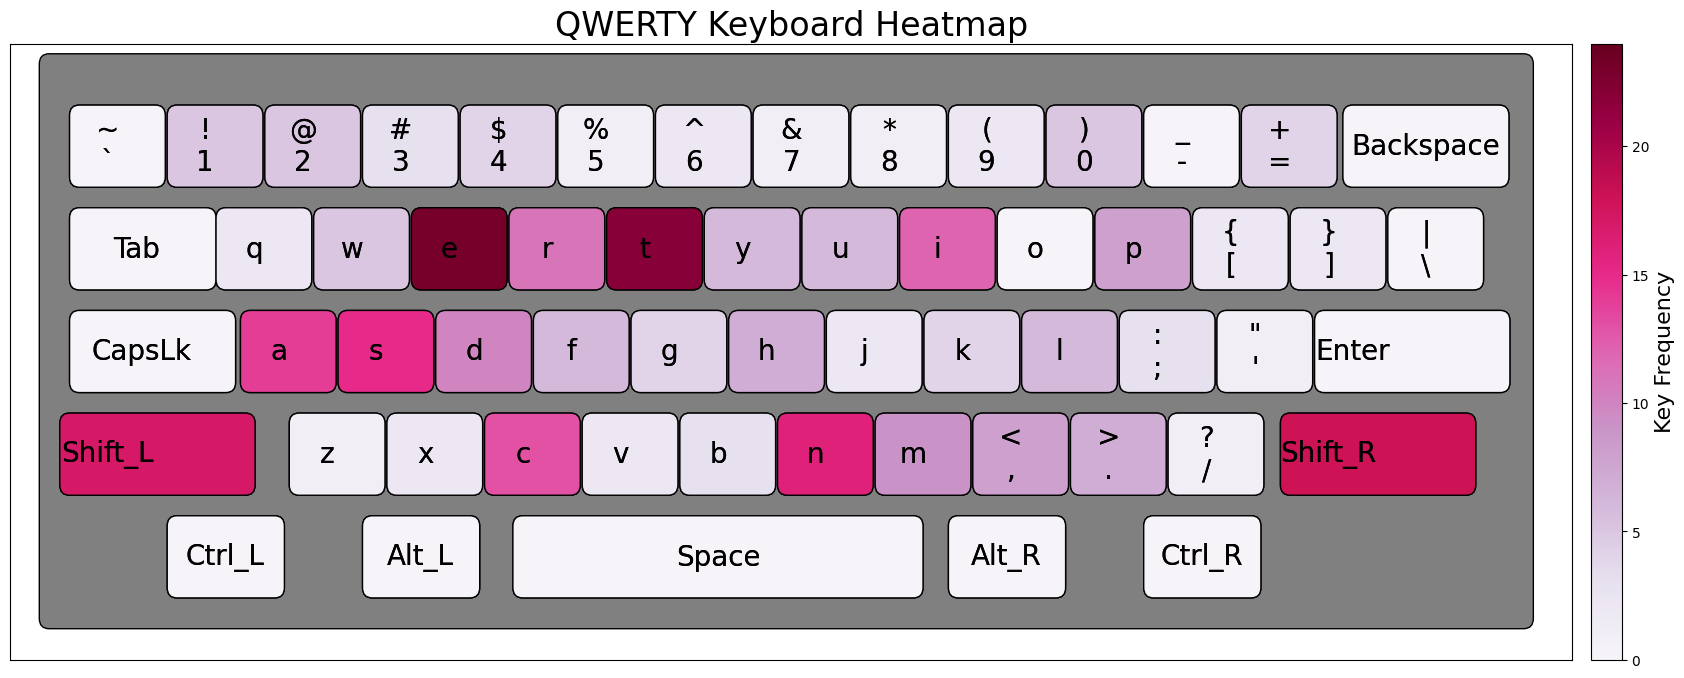

Total distance travelled by the fingers 493.2206489990107


In [17]:
# Example usage with text input
text_input = "The quick brown fox jumps over the lazy dog! @ 12:34 PM, $1000 was deposited in the account #1234567890. Press Shift+Tab to indent, or use Ctrl+C to copy. Don't forget to check emails at john.doe@example.com! For equations, try typing: E = mc^2,. Brackets come in many forms: ( ), [ ], { }, and even < >. Did you know that pressing Alt+F4 closes a window?"

Plotter(text_input, keys, characters)
total_distance = calculate_distance(text_input, keys, characters)
print("Total distance travelled by the fingers", total_distance)

In [ ]:
# Initialize the figure and axis
fig, ax = plt.subplots(figsize=(24, 8))

# Create the animation using FuncAnimation
anim = FuncAnimation(fig, generate_animated_heatmap, frames=len(text_input) + 1, interval=500, repeat=False)
anim.save('heatmap_animation_text_input2.mp4', writer='ffmpeg')
# Show the animated plot
plt.show()